## Feature-Based Model (Option A)

Train and evaluate the feature-based classifier. Include any baseline runs, metric reporting, and notes on model behavior.


In [2]:
from pathlib import Path
import sys

# Project root whether Jupyter cwd is repo root or notebooks/.
_root = Path.cwd().resolve()
if not (_root / "src").is_dir():
    _root = _root.parent
sys.path.insert(0, str(_root))

from src.config import (
    PART1_KAGGLE_DIR,
    PART1_TRAIN_DIR,
    PART2_IMAGES_DIR,
    PART2_ANNOTATIONS_DIR,
    validate_data_layout,
)

validate_data_layout()

print("Data paths validated:")
print(f"- Part 1: {PART1_KAGGLE_DIR}")
print(f"- Part 1 Train: {PART1_TRAIN_DIR}")
print(f"- Part 2 Images: {PART2_IMAGES_DIR}")
print(f"- Part 2 Annotations: {PART2_ANNOTATIONS_DIR}")

Data paths validated:
- Part 1: /home/cotte/github/school/ecse415-final-project/data/part1/data/kaggle
- Part 1 Train: /home/cotte/github/school/ecse415-final-project/data/part1/data/kaggle/train/train
- Part 2 Images: /home/cotte/github/school/ecse415-final-project/data/part2/Stanford Dog Dataset/Images
- Part 2 Annotations: /home/cotte/github/school/ecse415-final-project/data/part2/Stanford Dog Dataset/Annotation


In [3]:
import warnings
import time
from pathlib import Path
import sys

_root = Path.cwd().resolve()
if not (_root / "src").is_dir():
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.svm import SVC as SklearnSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

from src.config import LABEL_MAP_INV, PART1_TRAIN_DIR
from src.utils import resolve_svc, extract_hog_features, load_labeled_images_memmap

warnings.filterwarnings("ignore")

# False = CPU-only (sklearn SVC, no cuML); True = use CUDA for SVC when RAPIDS cuML is installed
USE_GPU = True

# HOG: same skimage + joblib chunking as Option B (``extract_multiscale_hog_hsv_features``)
FEAT_EXTRACT_N_JOBS = -1

IMG_SIZE = (64, 64)
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)

SVM_C = 10.0
SVM_KERNEL = "rbf"
SVM_GAMMA = "scale"

TEST_SIZE = 0.20
RANDOM_STATE = 42

CUDA_DEVICE_INDEX_A = 0
_has_cuda = torch.cuda.is_available()
_cuda_ok = False
if USE_GPU and _has_cuda:
    torch.cuda.set_device(CUDA_DEVICE_INDEX_A)
    _dev_try = torch.device("cuda", CUDA_DEVICE_INDEX_A)
    try:
        _ = torch.zeros(2, 2, device=_dev_try, dtype=torch.float32).mean()
        torch.cuda.synchronize()
        _cw = torch.nn.Conv2d(3, 8, kernel_size=3, padding=1).to(_dev_try)
        _ = _cw(torch.zeros(1, 3, 16, 16, device=_dev_try))
        torch.cuda.synchronize()
        _cuda_ok = True
    except RuntimeError:
        _cuda_ok = False

print("Option A | USE_GPU={} | CUDA usable for SVC (cuML): {}".format(USE_GPU, _cuda_ok))
if _has_cuda and USE_GPU and not _cuda_ok:
    print(
        "Note: PyTorch could not run CUDA kernels (wheel/arch mismatch); SVC stays on CPU."
    )

SVC, SklearnSVC, _ = resolve_svc(_cuda_ok, "Option A", prefer_gpu=USE_GPU)


Option A | USE_GPU=True | CUDA usable for SVC (cuML): True
Option A: cuml (GPU)


In [4]:



print("Loading from {} (cv2 resize to {})".format(PART1_TRAIN_DIR, IMG_SIZE))
X, y = load_labeled_images_memmap(img_size=IMG_SIZE, grayscale=False, rebuild=False)
print("Total training images: {}".format(X.shape[0]))

print("Extracting HOG features ...")
X = extract_hog_features(
    X,
    pixels_per_cell=HOG_PIXELS_PER_CELL,
    cells_per_block=HOG_CELLS_PER_BLOCK,
    orientations=HOG_ORIENTATIONS,
    n_jobs=FEAT_EXTRACT_N_JOBS,
)

class_names = [LABEL_MAP_INV[0], LABEL_MAP_INV[1]]

print("")
print("Feature vector size: {}".format(X.shape[1]))
print("Labels: 0={}, 1={}".format(class_names[0], class_names[1]))

Loading from /home/cotte/github/school/ecse415-final-project/data/part1/data/kaggle/train/train (cv2 resize to (64, 64))
Total training images: 20000
Extracting HOG features ...

Feature vector size: 1764
Labels: 0=cat, 1=dog


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,          # keeps cat/dog balance in both splits
)
print(f"Train samples : {len(X_train)}")
print(f"Test  samples : {len(X_test)}")

Train samples : 16000
Test  samples : 4000


In [6]:
# Pipeline: StandardScaler + SVC (cuML on CUDA + RAPIDS, else sklearn)
_svm_kw = dict(
    C=SVM_C,
    kernel=SVM_KERNEL,
    gamma=SVM_GAMMA,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
if SVC is SklearnSVC:
    _svm_kw["decision_function_shape"] = "ovr"

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(**_svm_kw)),
])

print("Training SVC ...")

# Start the timer
start_time = time.time()

model.fit(X_train, y_train)

# End the timer
end_time = time.time()

# Calculate duration
training_duration = (end_time - start_time)/60

print(f"Training complete in {training_duration:.2f} minutes")

y_pred = model.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

Training SVC ...
Training complete in 0.02 minutes
Test accuracy: 0.7833


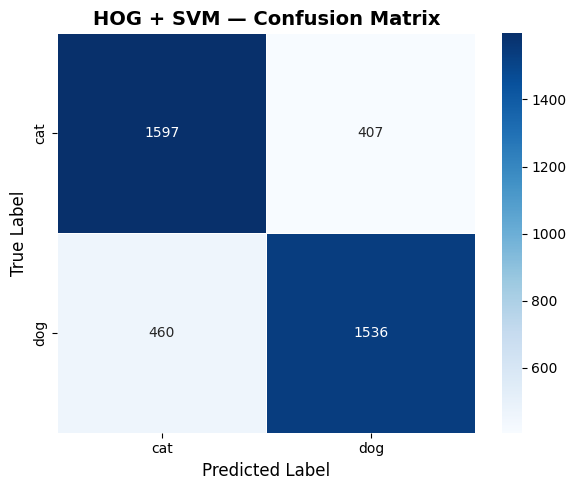

In [7]:
#Compute and display confusion matrix for Option A
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    ax=ax,
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("HOG + SVM — Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()